# 10-1. 차원축소

고차원의 데이터는 계산비용의 증가, 다중공선성 문제(Feature간 같은 정보를 가질 때)를 일으킬 수 있음.  
차원축소는 데이터의 노이즈를 줄이고, 더 좋은 학습결과를 얻을 수 있으며(중요한 특징만을 선별하여 모델링에 사용함으로써),  
데이터를 다루기 쉬워지고, 결과 이해가 쉬워짐

- Feature selection: 유용한 특성만 선별하여 사용
- Feature extraction: 기존 특성을 활용하여 새로운 특성 생성
  * PCA, LSA(=Truncated SVD), 요인분석(FA), 독립성분석(ICA), 음수 미포함 행렬 분해(NMF), 다차원척도법(MDS), t-SNE
- Clustering: 더 적은 수의 특성 사용

## 주성분분석
주성분분석(Principal Component Analysis, PCA)은 고차원 데이터를 더 적은 차원으로 축소하면서도 데이터의 **핵심적인 정보(분산)** 를   
최대한 보존하려는 통계 기법, 각 특징이 정규분포를 따른다고 가정하므로 스케일링이 필요

<장단점>
- 장점: 
  - 차원 축소: 많은 특성(feature)을 가진 데이터를 더 적은 수의 특성으로 요약해 계산 효율을 높이고, 과적합(overfitting) 방지
  - 시각화: 고차원 데이터를 2D 또는 3D로 줄여 시각적으로 이해하기 쉽게 만듬
  - 노이즈 제거: 중요하지 않은 축(분산이 적은 축)을 제거하면서 데이터의 잡음을 줄임
- 단점: 결과의 해석이 어려움, 데이터의 비선형 구조 반영 불가

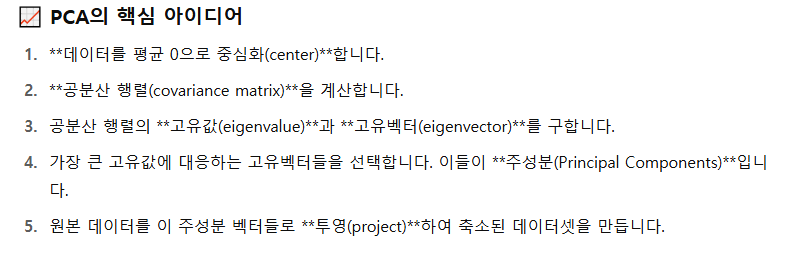

feature 개수: 13


,feat,고윳값,기여율,누적기여율
0,comp_1,4.767226,0.363953,0.363953
1,comp_2,2.438641,0.186177,0.550130
2,comp_3,1.554092,0.118647,0.668777
3,comp_4,0.965810,0.073735,0.742511
4,comp_5,0.895808,0.068390,0.810901
5,comp_6,0.594395,0.045379,0.856280
6,comp_7,0.490238,0.037427,0.893707
7,comp_8,0.347860,0.026557,0.920265
8,comp_9,0.300310,0.022927,0.943192
9,comp_10,0.252146,0.019250,0.962442


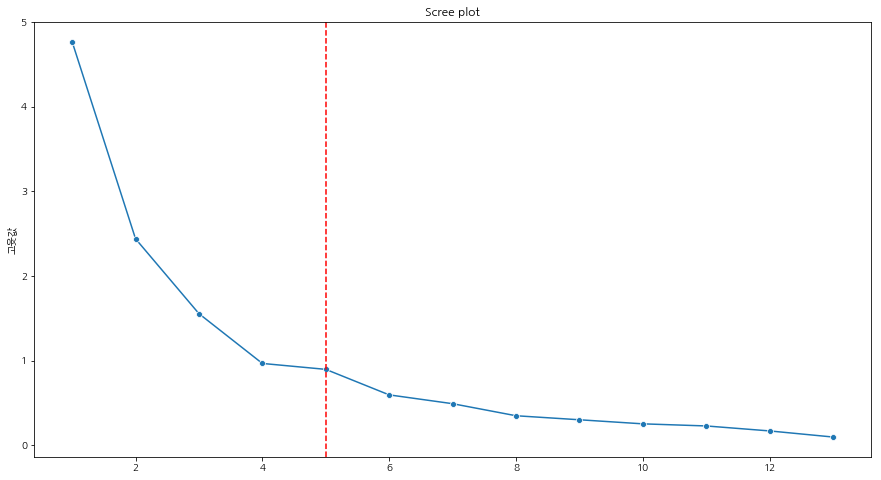

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from sklearn.datasets import load_wine
from collections import Counter
from sklearn.model_selection import train_test_split
import koreanize_matplotlib

warnings.filterwarnings('ignore')

X = pd.DataFrame(load_wine().data, columns=load_wine().feature_names)
Y = load_wine().target

print(f"feature 개수: {X.shape[1]}")

# 데이터분할: test 데이터의 정보를 학습에 사용하면 안 되기 때문에
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

#데이터표준화: PCA 전 필수
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
col_list = X.columns

s_train_X = pd.DataFrame(sc.fit_transform(train_X), columns=col_list)
s_test_X = pd.DataFrame(sc.transform(test_X), columns=col_list)

#PCA 적합
from sklearn.decomposition import PCA

pca = PCA(n_components=X.shape[1], svd_solver='auto') #전체 feature 수 입력
pca.fit(s_train_X)

#고윳값 요약
e_value = pd.DataFrame({'feat': ["comp_" + str(i) for i in range(1, X.shape[1]+1)], 
                        '고윳값': pca.explained_variance_, 
                        '기여율': pca.explained_variance_ratio_, 
                        '누적기여율': pca.explained_variance_ratio_.cumsum()})

display(e_value) 

#scree plot
plt.figure(figsize=(15, 8))
sns.lineplot(x=e_value.index+1, y='고윳값', data=e_value, marker='o')
plt.title('Scree plot')
plt.axvline(x=5, color='r', linestyle='--')
plt.show()

- 행: PCA로 만들어진 주성분 축
- 열: 기존 feature
- 값: 해당 주성분이 원래 변수에 대해 얼마나 **기여 또는 영향(기울기)** 을 받는지 나타냄. 즉, 가중치 계수(loading)

부호는 해당 변수의 기여 방향성을 나타내며, 절대값이 클 수 록 그 변수는 주성분의 생성에 크게 기여함

In [101]:
#차원축소
pca = PCA(n_components=0.8, svd_solver='auto') #개수로도 가능 5, 데이터 분산의 약 80%를 설명하는 데이터로 다시 재구성
rs = pca.fit_transform(s_train_X)

#생성된 PCA 결과
display(pd.DataFrame(rs, columns=["comp"+str(i) for i in range(1, rs.shape[1]+1)]).head(3))

# 고유벡터 요약
e_vector = pd.DataFrame(pca.components_, 
                        index=["comp"+str(i) for i in range(1, rs.shape[1]+1)], 
                       columns=X.columns)
e_vector

,comp1,comp2,comp3,comp4,comp5
0,-2.503736,-1.017953,0.990552,0.666305,0.193723
1,-0.787272,2.218381,-1.747150,-0.059183,0.281471
2,1.099291,0.994751,2.981664,0.848872,0.823151


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
comp1,-0.144523,0.248635,-0.001328,0.233386,-0.152495,-0.391592,-0.417079,0.286498,-0.325109,0.111803,-0.296526,-0.380898,-0.281035
comp2,-0.490819,-0.214372,-0.263762,0.091987,-0.263490,-0.063989,-0.004116,-0.052902,-0.024609,-0.547887,0.290208,0.158342,-0.385609
comp3,-0.136365,0.165345,0.651209,0.586834,0.105826,0.161220,0.176199,0.217558,0.106318,-0.103832,0.052004,0.189376,-0.096943
comp4,0.099843,0.528840,-0.165981,-0.078589,-0.627259,0.237096,0.190054,0.070809,0.262436,0.040513,-0.248287,0.190609,-0.131674
comp5,-0.298800,0.282190,-0.185497,0.088010,0.502570,0.013176,-0.025965,-0.472896,0.354678,0.013995,-0.359055,-0.034749,-0.236130


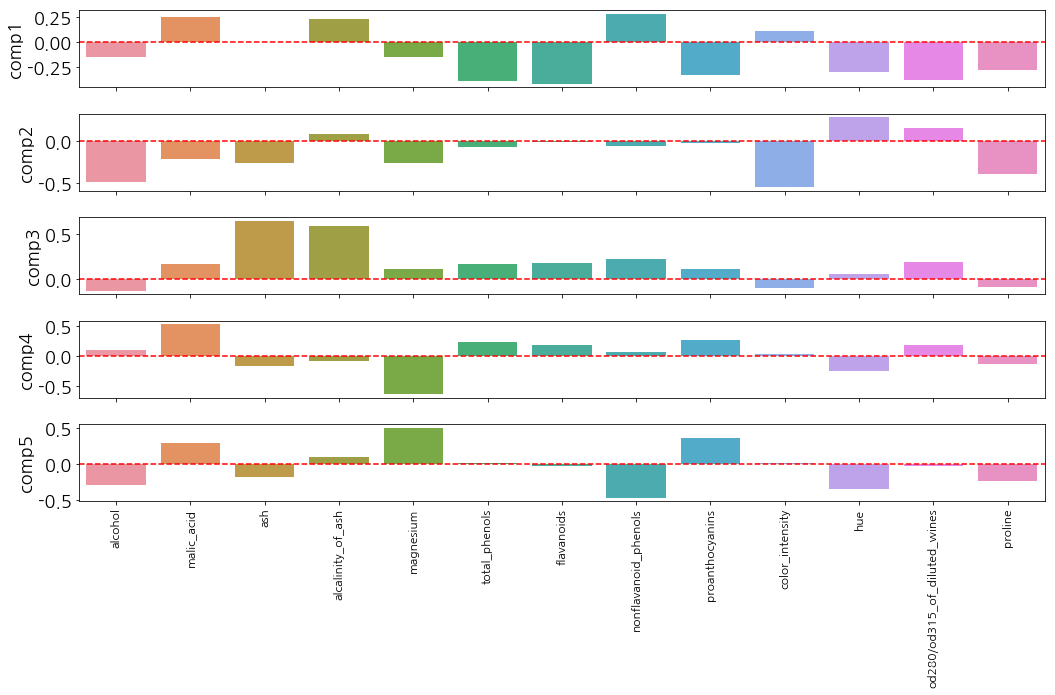

In [103]:
fig, ax = plt.subplots(rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(e_vector.index):
    sns.barplot(x=e_vector.columns, y=e_vector.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(e_vector.columns), rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

biplot을 통한 pca 결과 해석
1. 각 pc축에 가깝게 평행을 이루는 변수가 해당 pc에 가장 영향을 많이 주는 변수
2. 각 빨간선의 길이는 원 변수의 분산을 표현, 길이가 길수록 분산이 큼
3. 각 빨간선이 가까울수록 서로 상관관계가 있음

아래 결과는 PC1은 기존 데이터에서 36.4%의 분산설명률을 가지고 있고, PC2는 18.6%의 설명률을 가지고 있다.  
ash 등 PC2와 평행을 이루는 변수가 PC2에 많은 영향을 주고 있으며, ash와 alcohol과 빨간선이 가까우므로 서로 상관관계가 있는 것으로  
관찰된다. alcohol보다 ash가 화살표가 짧으므로 작은 분산을 가진다고 볼 수 있다.

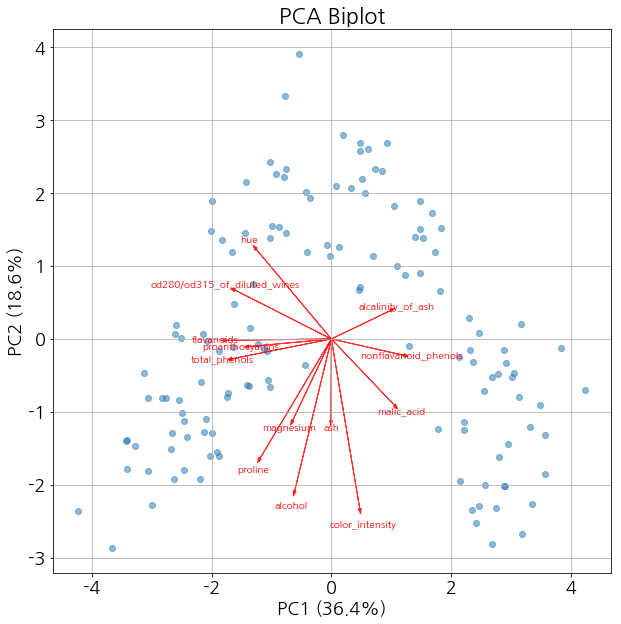

In [107]:
#biplot을 통한 pca 결과 해석: 지원x

# 변수 이름 (열 이름)
features = s_train_X.columns

# Biplot 그리기
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. 샘플 점수 시각화
ax.scatter(rs[:, 0], rs[:, 1], alpha=0.5)

# 2. 변수 벡터 시각화
for i, feature in enumerate(features):
    vector = pca.components_[:, i] * max(rs[:, 0].max(), rs[:, 1].max())  # 스케일 맞추기
    ax.arrow(0, 0, vector[0], vector[1], color='r', alpha=0.8, head_width=0.05)
    ax.text(vector[0]*1.1, vector[1]*1.1, feature, color='r', ha='center', va='center', fontsize=10)

# 축 라벨
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA Biplot")

plt.grid()
plt.show()

## 요인분석

변수들 간의 상관관계를 분석하여 공통 차원들을 통해 축약하는 통계기법으로 다수 변수들의 정보 손실을 최소화하면서 소수의 요인으로 축약  
잠재변수에 대해 연결된 분산을 찾고, 오차를 추가한 인자들의 선형결합으로 관측된 변수들을 표현  
FA의 잠재변수들은 기본적으로 대등한 관계(PCA는 다른성분보다 중요한 변수가 있음)   
- 탐색적 요인분석(EFA): 변수가 어느 요인에 부합될지에 대한 가설이 없을 시
- 확인요인분석(CFA): 변수와 요인에 대한 특정한 가설을 토대로 요인 분석모델과 자료가 부합하는지 확인할 때

요인분석을 통해 변수축소(여러 개의 관련있는 변수들이 하나의 요인으로 묶임), 불필요한 변수 제거(요인에 포함되지 않거나 포함되더라도  
중요도가 낮은 변수를 찾을 수 있음), 변수특성파악(관련된 변수들이 묶임으로써 요인들의 상호독립적인 특성을 파악), 요인점수를 이용한  
변수생성을 할 수 있음

| 항목                                | 의미                                                          |
| --------------------------------- | ----------------------------------------------------------- |
| **행** (`latent1`, ..., `latent5`) | 잠재 요인 (Factor 1\~5)                                         |
| **열** (`alcohol`, ..., `proline`) | 원래 변수                                                       |
| **값**                             | 해당 요인이 변수에 미치는 영향력 (factor loading). **값의 절댓값이 클수록 중요한 기여** |

- latent1: total_phenols, flavanoids,od280/od315 등이 강하게 작용 → 해당변수는 와인의 복합성, 구조감, 바디감 관련 요인

In [123]:
# 위 데이터 그대로 사용

print(f"feature {X.shape[1]} 개, 데이터 {X.shape[0]} 개")

#스케일링한 데이터도 그대로 사용
#FA 적합
from sklearn.decomposition import FactorAnalysis

model = FactorAnalysis(n_components=5) # 개수로 지정 가능
fa_rs = model.fit_transform(s_train_X)


#각 잠재요인의 feature별 최대분산
max_var = pd.DataFrame(model.components_, index=['latent'+str(i) for i in range(1, fa_rs.shape[1]+1)], columns=X.columns)
display(max_var)

feature 13 개, 데이터 178 개


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
latent1,0.295282,-0.420644,0.169510,-0.360643,0.277493,0.884448,0.963883,-0.508652,0.681593,-0.206900,0.569396,0.833304,0.554107
latent2,-0.380197,-0.305525,-0.863617,-0.364810,-0.347989,-0.019923,0.017631,-0.265978,0.082495,-0.555727,0.318594,0.185960,-0.301902
latent3,-0.578215,-0.011438,0.352945,0.593245,-0.263541,-0.052483,0.036310,0.178472,-0.087289,-0.624607,0.253030,0.219282,-0.517197
latent4,-0.156267,-0.252018,0.001590,-0.012868,0.690143,-0.092972,-0.089514,-0.194173,0.045054,-0.207965,0.222615,0.002163,0.069595
latent5,-0.215182,0.261957,-0.079024,0.203368,0.192270,0.110807,0.065619,-0.102225,0.258895,0.145468,-0.349925,-0.041607,-0.306477


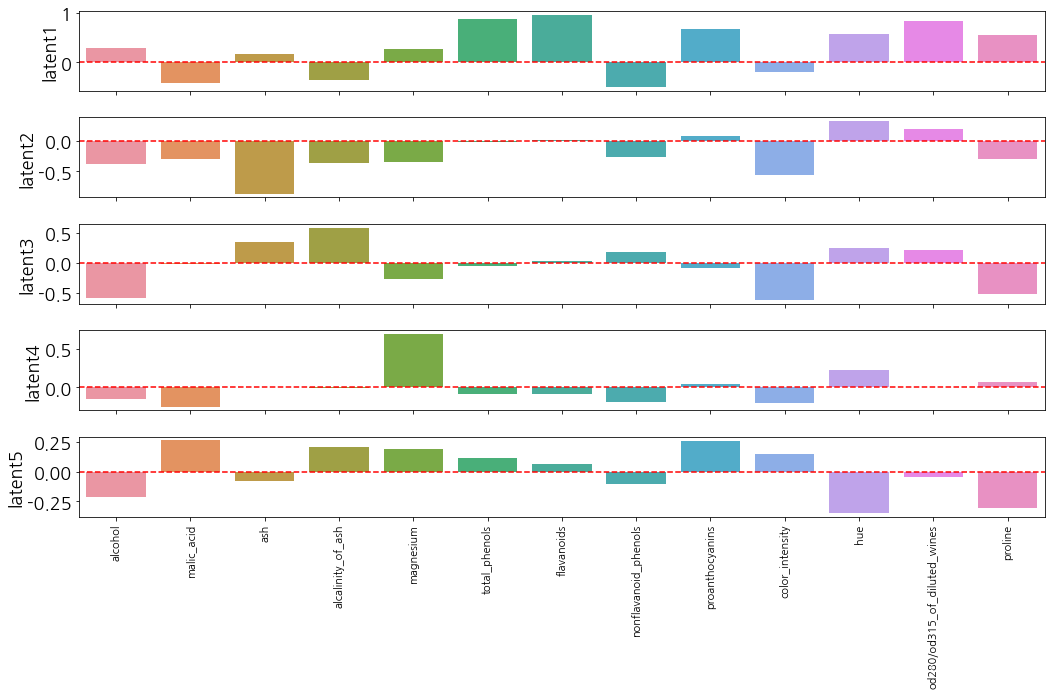

In [125]:
fig, ax = plt.subplots(fa_rs.shape[1], 1, figsize=(15, 10))

for i, idx in enumerate(max_var.index):
    sns.barplot(x=max_var.columns, y=max_var.iloc[i], ax=ax[i])
    ax[i].axhline(y=0, color='r', linestyle='--')
    if i != 4:
        ax[i].set_xticklabels([])
    else:
        ax[i].set_xticklabels(list(max_var.columns), rotation=90, fontsize=11)
plt.tight_layout()
plt.show()

## 독립성분 분석